In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU nahi mila! Runtime -> Change runtime type -> T4 GPU")

CUDA available: True
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q timm grad-cam scikit-learn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
import os, re, time, random, json, zipfile
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import requests
from urllib.parse import urljoin
from IPython.display import display

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, roc_curve

SEED = 42
def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_all()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Paths (sab Drive mein, taake session band hone par bhi bacha rahe)
ROOT     = Path('/content/drive/MyDrive/tb-generalization')
CK       = ROOT / 'checkpoints'
RES      = ROOT / 'results'
CACHE    = ROOT / 'cache'      # resized images
DRV_DATA = ROOT / 'data'       # yahan TBX11K ki zip rakhni hai
LOCAL    = Path('/content/data')
for p in [CK, RES, CACHE, DRV_DATA, LOCAL]:
    p.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
ARCH     = 'densenet121'
DATASETS = ['shenzhen', 'montgomery', 'tbx11k']
EPOCHS   = {'shenzhen': 15, 'montgomery': 25, 'tbx11k': 8}
BATCH, LR = 32, 1e-4
print("Setup OK | device:", DEVICE, "| arch:", ARCH)

Setup OK | device: cuda | arch: densenet121


In [9]:
r = S.get(START['shenzhen'] + 'index.html', timeout=60)
print(r.status_code); print(r.text[:300])

200
<!DOCTYPE html><html><head><meta http-equiv='content-type' content='text/html; charset=utf-8'><meta name='viewport' content='width=device-width'><style type='text/css'>body,html {background:#fff;font-family:'Bitstream Vera Sans','Lucida Grande','Lucida Sans Unicode',Lucidux,Verdana,Lucida,sans-serif


In [11]:
import shutil

S = requests.Session()
S.headers.update({'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                                '(KHTML, like Gecko) Chrome/124.0 Safari/537.36'})

NLM = 'https://data.lhncbc.nlm.nih.gov/public/Tuberculosis-Chest-X-ray-Datasets/'
START = {'shenzhen':   NLM + 'Shenzhen-Hospital-CXR-Set/',
         'montgomery': NLM + 'Montgomery-County-CXR-Set/'}
EXPECTED = {'shenzhen': 662, 'montgomery': 138}

HREF = re.compile(r"""href=['"]([^'"]+)['"]""", re.I)   # single AUR double quote dono

def fetch_index(url):
    if not url.endswith('.html'):
        url = url.rstrip('/') + '/index.html'
    r = S.get(url, timeout=60)
    r.raise_for_status()
    return url, r.text

def find_cxr_png_files(start, max_depth=3):
    queue, seen = [(start, 0)], set()
    while queue:
        url, d = queue.pop(0)
        try:
            url, html = fetch_index(url)
        except Exception as e:
            print('skip:', url, '->', e); continue
        if url in seen:
            continue
        seen.add(url)
        hrefs = HREF.findall(html)
        pngs = sorted(set(urljoin(url, h) for h in hrefs if h.lower().endswith('.png')))
        print(f'  dekha: {url.replace(NLM, "")} | links={len(hrefs)} png={len(pngs)}')
        if 'cxr_png' in url.lower() and len(pngs) > 50:
            print('Mil gaya:', len(pngs), 'images')
            return pngs
        if d < max_depth:
            for h in hrefs:
                nxt = urljoin(url, h)
                if nxt.startswith(start) and (h.endswith('/') or h.endswith('.html')) and nxt not in seen:
                    queue.append((nxt, d + 1))
    return []

def download_one(args):
    url, out_dir = args
    out = out_dir / url.split('/')[-1]
    if out.exists() and out.stat().st_size > 0:
        return True
    for _ in range(3):
        try:
            r = S.get(url, timeout=180); r.raise_for_status()
            out.write_bytes(r.content); return True
        except Exception:
            time.sleep(2)
    print('FAILED:', url); return False

def get_nlm(name):
    out_dir = LOCAL / name
    out_dir.mkdir(parents=True, exist_ok=True)
    if len(list(out_dir.glob('*.png'))) >= EXPECTED[name]:
        print(name, 'pehle se maujood'); return
    urls = find_cxr_png_files(START[name])
    if not urls:
        raise RuntimeError(f'{name}: links nahi mile, upar "dekha:" wali lines bhej do.')
    print(f'{name}: {len(urls)} images download ho rahi hain (Shenzhen ~4 GB, kuch minute lagenge)...')
    with ThreadPoolExecutor(8) as ex:
        list(ex.map(download_one, [(u, out_dir) for u in urls]))
    n_files = len(list(out_dir.glob('*.png')))
    print(name, 'done:', n_files, 'files | expected', EXPECTED[name])

need_cache = [n for n in DATASETS if not (CACHE / f'{n}_{IMG_SIZE}.npy').exists()]
for n in ['shenzhen', 'montgomery']:
    if n in need_cache:
        get_nlm(n)
    else:
        print(n, ': cache maujood, skip')

  dekha: Shenzhen-Hospital-CXR-Set/index.html | links=6 png=0
  dekha: Shenzhen-Hospital-CXR-Set/Annotations-2/index.html | links=4 png=0
  dekha: Shenzhen-Hospital-CXR-Set/Annotations/index.html | links=4 png=0
  dekha: Shenzhen-Hospital-CXR-Set/CXR_png/index.html | links=662 png=662
Mil gaya: 662 images
shenzhen: 662 images download ho rahi hain (Shenzhen ~4 GB, kuch minute lagenge)...
shenzhen done: 662 files | expected 662
  dekha: Montgomery-County-CXR-Set/index.html | links=1 png=0
  dekha: Montgomery-County-CXR-Set/MontgomerySet/index.html | links=5 png=0
  dekha: Montgomery-County-CXR-Set/MontgomerySet/CXR_png/index.html | links=138 png=138
Mil gaya: 138 images
montgomery: 138 images download ho rahi hain (Shenzhen ~4 GB, kuch minute lagenge)...
montgomery done: 138 files | expected 138


In [ ]:
!pip install -q gdown
import gdown

TBX_LINK = 'YAHAN_COPY_KIYA_HUA_LINK_PASTE_KARO'
out_zip = str(DRV_DATA / 'tbx11k.zip')

if '/folders/' in TBX_LINK:
    gdown.download_folder(TBX_LINK, output=str(DRV_DATA / 'tbx_raw'), quiet=False)
else:
    gdown.download(TBX_LINK, out_zip, quiet=False, fuzzy=True)

In [13]:
!pip install -q gdown
import gdown

TBX_LINK = 'https://drive.google.com/file/d/1r-oNYTPiPCOUzSjChjCIYTdkjBTugqxR/view?usp=sharing'
out_zip = str(DRV_DATA / 'tbx11k.zip')

if '/folders/' in TBX_LINK:
    gdown.download_folder(TBX_LINK, output=str(DRV_DATA / 'tbx_raw'), quiet=False)
else:
    gdown.download(TBX_LINK, out_zip, quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1r-oNYTPiPCOUzSjChjCIYTdkjBTugqxR
From (redirected): https://drive.google.com/uc?id=1r-oNYTPiPCOUzSjChjCIYTdkjBTugqxR&confirm=t&uuid=b4a7689f-1655-4fcf-8abe-67c5da0e9d4c
To: /content/drive/MyDrive/tb-generalization/data/tbx11k.zip
100%|██████████| 3.31G/3.31G [00:36<00:00, 91.4MB/s]


In [14]:
def prepare_tbx11k():
    out = LOCAL / 'tbx11k'
    if any(out.rglob('*.png')) or any(out.rglob('*.jpg')):
        print('TBX11K pehle se unzip hai'); return

    zips = [p for p in DRV_DATA.rglob('*.zip') if 'tbx' in p.name.lower()]
    if not zips:
        raise FileNotFoundError('Drive ke data folder mein tbx11k.zip nahi mili.')
    z_drive = zips[0]
    print(f'Drive se zip mili: {z_drive.name} ({z_drive.stat().st_size / 1e9:.2f} GB)')

    if not zipfile.is_zipfile(z_drive):
        raise RuntimeError('Ye asal zip nahi hai (gdown ne shayad error page save kiya). Download dobara karo.')

    out.mkdir(parents=True, exist_ok=True)
    print('Unzip ho rahi hai (thora time lagega)...')
    with zipfile.ZipFile(z_drive) as z:
        z.extractall(out)

    n = sum(1 for _ in out.rglob('*.png')) + sum(1 for _ in out.rglob('*.jpg'))
    print('Done. Total images mili:', n)

if 'tbx11k' in need_cache:
    prepare_tbx11k()
else:
    print('tbx11k: cache maujood, unzip skip')

Drive se zip mili: tbx11k.zip (3.31 GB)
Unzip ho rahi hai (thora time lagega)...
Done. Total images mili: 12279


In [15]:
def load_gray(p):
    im = Image.open(p).convert('L').resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    return np.asarray(im, dtype=np.uint8)

def meta_nlm(name):
    files = sorted((LOCAL / name).glob('*.png'))
    rows = []
    for f in files:
        lab = int(f.stem.split('_')[-1])       # ..._0 normal, ..._1 TB
        rows.append(dict(path=str(f), label=lab, cls='tb' if lab == 1 else 'normal'))
    return pd.DataFrame(rows)

def norm_cls(t):
    t = str(t).lower()
    if 'health' in t or 'normal' in t: return 'healthy'
    if 'sick' in t or 'non' in t:      return 'sick'
    if 'tb' in t:                      return 'tb'
    return None

def meta_tbx():
    root = LOCAL / 'tbx11k'
    imgs = {p.name: p for p in root.rglob('*') if p.suffix.lower() in ('.png', '.jpg', '.jpeg')}
    rows, skipped = [], 0
    csvs = list(root.rglob('data.csv'))
    if csvs:                                    # Kaggle simplified version
        df = pd.read_csv(csvs[0]); print('data.csv columns:', df.columns.tolist())
        fcol = next(c for c in df.columns if c.lower() in ('fname', 'filename', 'file', 'image', 'image_id'))
        tcol = next(c for c in df.columns if c.lower() in ('target', 'label', 'class'))
        for f, t in zip(df[fcol], df[tcol]):
            name = os.path.basename(str(f)); c = norm_cls(t)
            if name not in imgs and (name + '.png') in imgs: name += '.png'
            if name in imgs and c: rows.append(dict(path=str(imgs[name]), cls=c))
            else: skipped += 1
    else:                                       # original layout: imgs/health, imgs/sick, imgs/tb
        for name, p in imgs.items():
            c = norm_cls(p.parent.name)
            if c: rows.append(dict(path=str(p), cls=c))
            else: skipped += 1
    m = pd.DataFrame(rows); m['label'] = (m['cls'] == 'tb').astype(int)
    print(f'TBX11K: {len(m)} labeled images, {skipped} skipped (unlabeled/test)')
    print(m['cls'].value_counts().to_dict())
    return m

def build_dataset(name):
    meta = (meta_tbx() if name == 'tbx11k' else meta_nlm(name)).reset_index(drop=True)
    assert len(meta) > 50, f'{name}: images nahi mili, Step 1.1/1.2 check karo'
    meta['dataset'] = name
    sizes = []
    for p in meta['path']:
        with Image.open(p) as im: sizes.append(im.size)
    meta['width'] = [s[0] for s in sizes]; meta['height'] = [s[1] for s in sizes]
    print(name, ': resize ho rahi hain...')
    with ThreadPoolExecutor(8) as ex:
        X = np.stack(list(ex.map(load_gray, meta['path'])))
    flat = X.reshape(len(X), -1)
    meta['brightness'] = flat.mean(1); meta['contrast'] = flat.std(1)
    idx = np.arange(len(meta))
    tr, tmp = train_test_split(idx, test_size=0.30, stratify=meta['label'], random_state=SEED)
    va, te = train_test_split(tmp, test_size=0.50, stratify=meta['label'].values[tmp], random_state=SEED)
    meta['split'] = 'train'; meta.loc[va, 'split'] = 'val'; meta.loc[te, 'split'] = 'test'
    np.save(CACHE / f'{name}_{IMG_SIZE}.npy', X)
    meta.to_csv(CACHE / f'{name}_meta.csv', index=False)
    return meta

for n in DATASETS:
    if not (CACHE / f'{n}_{IMG_SIZE}.npy').exists():
        build_dataset(n)

META = {n: pd.read_csv(CACHE / f'{n}_meta.csv') for n in DATASETS}
XS   = {n: np.load(CACHE / f'{n}_{IMG_SIZE}.npy') for n in DATASETS}
for n in DATASETS:
    print(n, XS[n].shape, META[n]['split'].value_counts().to_dict())

shenzhen : resize ho rahi hain...
montgomery : resize ho rahi hain...
TBX11K: 8401 labeled images, 3878 skipped (unlabeled/test)
{'healthy': 3800, 'sick': 3800, 'tb': 801}
tbx11k : resize ho rahi hain...
shenzhen (662, 224, 224) {'train': 463, 'test': 100, 'val': 99}
montgomery (138, 224, 224) {'train': 96, 'val': 21, 'test': 21}
tbx11k (8401, 224, 224) {'train': 5880, 'test': 1261, 'val': 1260}


,dataset,images,TB,non_TB,TB_pct,typical_size,brightness_mean,contrast_mean
0,shenzhen,662,336,326,50.8,2744x2937,156.7,63.0
1,montgomery,138,58,80,42.0,4020x4892,112.9,82.2
2,tbx11k,8401,801,7600,9.5,512x512,134.2,64.2


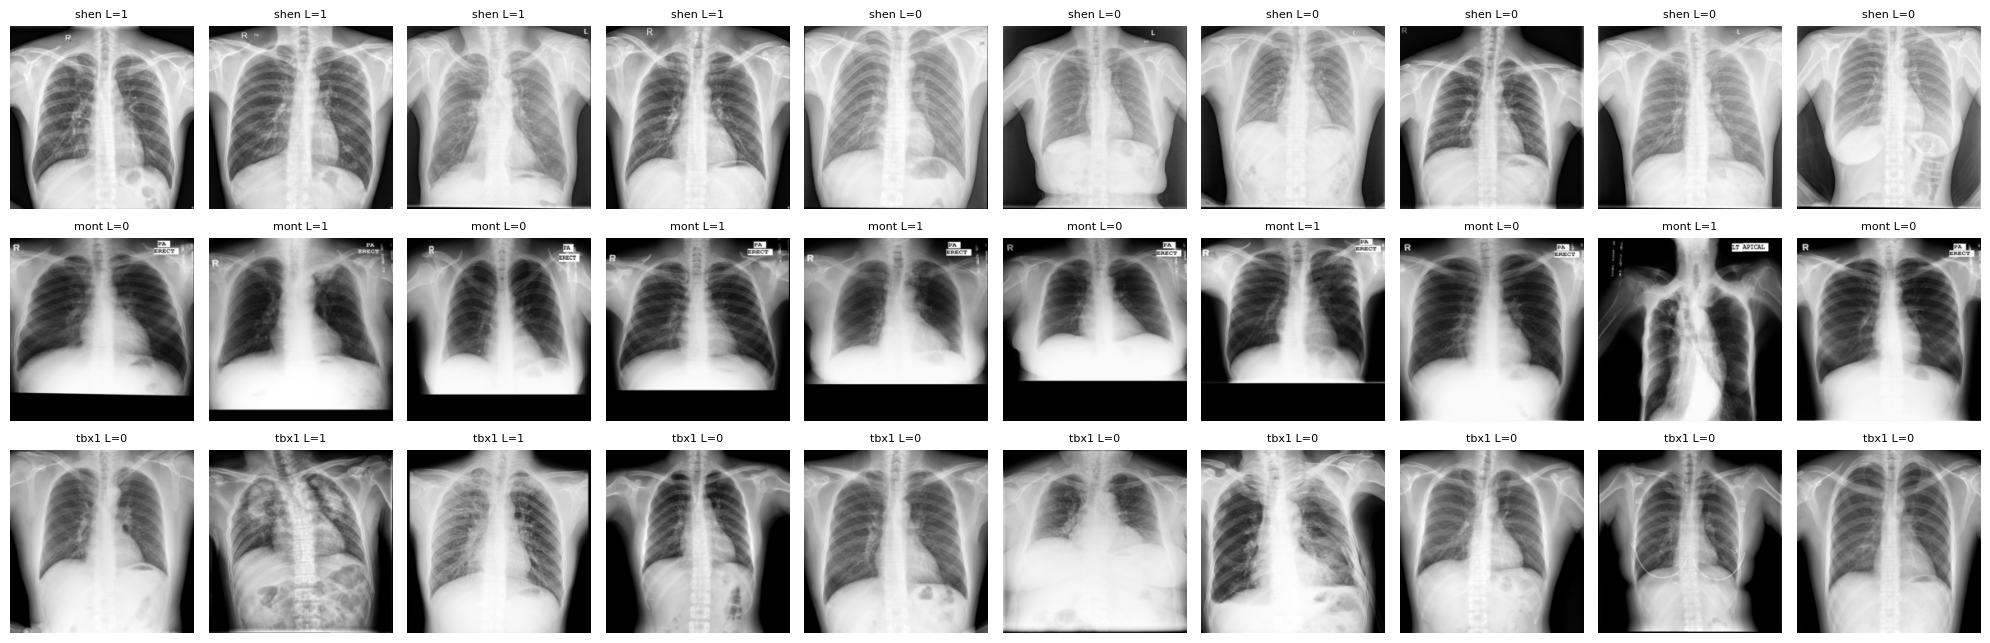

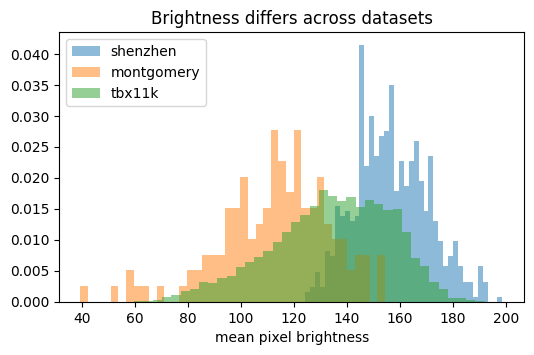

In [16]:
rows = []
for n in DATASETS:
    m = META[n]
    rows.append(dict(dataset=n, images=len(m), TB=int(m.label.sum()), non_TB=int((1 - m.label).sum()),
                     TB_pct=round(100 * m.label.mean(), 1),
                     typical_size=f"{int(m.width.median())}x{int(m.height.median())}",
                     brightness_mean=round(m.brightness.mean(), 1), contrast_mean=round(m.contrast.mean(), 1)))
eda = pd.DataFrame(rows); display(eda); eda.to_csv(RES / 'eda_summary.csv', index=False)

# 10 random images per dataset
fig, axes = plt.subplots(len(DATASETS), 10, figsize=(20, 2.2 * len(DATASETS)))
rng = np.random.default_rng(0)
for r, n in enumerate(DATASETS):
    pick = rng.choice(len(XS[n]), 10, replace=False)
    for c, i in enumerate(pick):
        axes[r, c].imshow(XS[n][i], cmap='gray'); axes[r, c].axis('off')
        axes[r, c].set_title(f"{n[:4]} L={META[n].label[i]}", fontsize=8)
plt.tight_layout(); plt.savefig(RES / 'eda_samples.png', dpi=120); plt.show()

# brightness distribution
plt.figure(figsize=(6, 3.5))
for n in DATASETS: plt.hist(META[n].brightness, bins=40, alpha=0.5, label=n, density=True)
plt.xlabel('mean pixel brightness'); plt.legend(); plt.title('Brightness differs across datasets')
plt.savefig(RES / 'eda_brightness.png', dpi=120); plt.show()

In [17]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
rot = T.RandomRotation(10)

class CXRDataset(Dataset):
    def __init__(self, X, y, train=False):
        self.X = torch.from_numpy(X); self.y = torch.from_numpy(np.asarray(y, dtype=np.float32)); self.train = train
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        x = self.X[i].float().div_(255.).unsqueeze(0)          # 1xHxW, 0..1
        if self.train:                                          # halka augmentation (flip nahi: dil ki position)
            x = rot(x)
            c, b = random.uniform(0.8, 1.2), random.uniform(-0.1, 0.1)
            x = ((x - 0.5) * c + 0.5 + b).clamp_(0, 1)
        x = x.repeat(3, 1, 1)                                   # grayscale -> 3 channel
        return (x - MEAN) / STD, self.y[i]

def get_xy(name, split=None):
    m = META[name]
    idx = np.where(m['split'].values == split)[0] if split else np.arange(len(m))
    return XS[name][idx], m['label'].values[idx], idx

def get_xy_multi(names, split):
    parts = [get_xy(n, split) for n in names]
    return np.concatenate([p[0] for p in parts]), np.concatenate([p[1] for p in parts])

In [22]:
def get_model(pretrained=True):
    return timm.create_model(ARCH, pretrained=pretrained, num_classes=1)

def load_best(tag):
    model = get_model(pretrained=False).to(DEVICE)
    ck = torch.load(CK / f'{tag}_best.pt', map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck['model'])
    return model.eval()

@torch.no_grad()
def predict_logits(model, X, bs=64):
    model.eval()
    dl = DataLoader(CXRDataset(X, np.zeros(len(X))), batch_size=bs, shuffle=False, num_workers=2)
    out = []
    for xb, _ in dl:
        with torch.autocast('cuda', enabled=(DEVICE == 'cuda')):
            out.append(model(xb.to(DEVICE)).float().reshape(-1).cpu())
    return torch.cat(out).numpy()

In [23]:
def train_model(tag, names, epochs, lr=LR, bs=BATCH, patience=6):
    last, best = CK / f'{tag}_last.pt', CK / f'{tag}_best.pt'
    Xtr, ytr = get_xy_multi(names, 'train'); Xva, yva = get_xy_multi(names, 'val')
    model = get_model().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    pos_w = torch.tensor([(ytr == 0).sum() / max((ytr == 1).sum(), 1)], dtype=torch.float32, device=DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)             # class imbalance ke liye
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))
    start, best_auc, bad, done = 0, -1.0, 0, False
    if last.exists():                                         # session toota tha? wahin se resume
        ck = torch.load(last, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ck['model']); opt.load_state_dict(ck['optim'])
        start, best_auc, bad, done = ck['epoch'] + 1, ck['best_auc'], ck['bad'], ck['done']
        print(f'[{tag}] resume: epoch {start}, best val AUC {best_auc:.4f}, done={done}')
    if done:
        return
    dl = DataLoader(CXRDataset(Xtr, ytr, train=True), batch_size=bs, shuffle=True, num_workers=2,
                    pin_memory=True, drop_last=len(ytr) > bs)
    for ep in range(start, epochs):
        model.train(); tot = 0.0; t0 = time.time()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast('cuda', enabled=(DEVICE == 'cuda')):
                out = model(xb).reshape(-1)
            loss = crit(out.float(), yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tot += loss.item() * len(yb)
        val_auc = roc_auc_score(yva, predict_logits(model, Xva))
        if val_auc > best_auc:
            best_auc, bad = val_auc, 0
            torch.save({'model': model.state_dict(), 'epoch': ep, 'val_auc': val_auc}, best)
        else:
            bad += 1
        done = (bad >= patience) or (ep == epochs - 1)
        torch.save({'epoch': ep, 'model': model.state_dict(), 'optim': opt.state_dict(),
                    'best_auc': best_auc, 'bad': bad, 'done': done}, last)      # har epoch checkpoint
        print(f'[{tag}] epoch {ep+1}/{epochs} loss {tot/len(ytr):.4f} val AUC {val_auc:.4f} ({time.time()-t0:.0f}s)')
        if done:
            break

In [24]:
def sigmoid(z): return 1 / (1 + np.exp(-z))

def sens_spec(y, p, thr):
    pred = p >= thr
    tp = (pred & (y == 1)).sum(); fn = (~pred & (y == 1)).sum()
    tn = (~pred & (y == 0)).sum(); fp = (pred & (y == 0)).sum()
    return tp / max(tp + fn, 1), tn / max(tn + fp, 1)

def thr_for_sens(y, p, target=0.90):
    """Wo threshold jis par kam az kam target fraction TB cases pakde jayen."""
    pos = np.sort(p[y == 1]); k = int(np.floor((1 - target) * len(pos)))
    return pos[k]

def auc_ci(y, p, n=500, seed=0):
    rng = np.random.default_rng(seed); a = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2: continue
        a.append(roc_auc_score(y[i], p[i]))
    return np.percentile(a, [2.5, 97.5])

In [25]:
RES_CSV = RES / 'cross_dataset.csv'

def run_all():
    done = pd.read_csv(RES_CSV) if RES_CSV.exists() else pd.DataFrame()
    rows = done.to_dict('records')
    have = {(r['train'], r['test']) for r in rows}
    for tr in DATASETS:
        todo = [te for te in DATASETS if (tr, te) not in have]
        if not todo: continue
        print(f'\n===== TRAIN on {tr} =====')
        train_model(tr, [tr], EPOCHS[tr])
        model = load_best(tr)
        Xv, yv, _ = get_xy(tr, 'val'); lv = predict_logits(model, Xv)
        np.savez(RES / f'val_{tr}.npz', y=yv, logits=lv)
        thr_src = thr_for_sens(yv, sigmoid(lv), 0.90)
        for te in todo:
            Xt, yt, idx = get_xy(te, 'test' if te == tr else None)
            lt = predict_logits(model, Xt); p = sigmoid(lt)
            np.savez(RES / f'preds_{tr}_{te}.npz', y=yt, logits=lt, idx=idx)
            lo, hi = auc_ci(yt, p)
            sens, spec = sens_spec(yt, p, thr_src)
            own_thr = thr_for_sens(yt, p, 0.90); _, spec_own = sens_spec(yt, p, own_thr)
            rows.append(dict(train=tr, test=te, eval_on='test split' if te == tr else 'full dataset', n=len(yt),
                             auc=roc_auc_score(yt, p), auc_lo=lo, auc_hi=hi,
                             thr_src=thr_src, sens_at_srcthr=sens, spec_at_srcthr=spec,
                             f1_at_srcthr=f1_score(yt, p >= thr_src), spec_at_own_90sens=spec_own))
            pd.DataFrame(rows).to_csv(RES_CSV, index=False)
            print(f'  {tr} -> {te}: AUC {rows[-1]["auc"]:.3f} [{lo:.3f}, {hi:.3f}] | '
                  f'sens {sens:.2f} spec {spec:.2f} @ source threshold')
        del model; torch.cuda.empty_cache()

run_all()


===== TRAIN on shenzhen =====
[shenzhen] resume: epoch 15, best val AUC 0.9233, done=True
  shenzhen -> shenzhen: AUC 0.920 [0.865, 0.971] | sens 0.90 spec 0.82 @ source threshold
  shenzhen -> montgomery: AUC 0.792 [0.711, 0.859] | sens 0.91 spec 0.42 @ source threshold
  shenzhen -> tbx11k: AUC 0.720 [0.700, 0.739] | sens 0.88 spec 0.32 @ source threshold

===== TRAIN on montgomery =====
[montgomery] epoch 1/25 loss 0.8224 val AUC 0.4630 (3s)
[montgomery] epoch 2/25 loss 0.7732 val AUC 0.4352 (2s)
[montgomery] epoch 3/25 loss 0.7486 val AUC 0.4444 (2s)
[montgomery] epoch 4/25 loss 0.6635 val AUC 0.5000 (2s)
[montgomery] epoch 5/25 loss 0.6365 val AUC 0.4815 (2s)
[montgomery] epoch 6/25 loss 0.5703 val AUC 0.5370 (2s)
[montgomery] epoch 7/25 loss 0.5276 val AUC 0.6204 (2s)
[montgomery] epoch 8/25 loss 0.5275 val AUC 0.6759 (3s)
[montgomery] epoch 9/25 loss 0.4578 val AUC 0.6667 (2s)
[montgomery] epoch 10/25 loss 0.4230 val AUC 0.6759 (2s)
[montgomery] epoch 11/25 loss 0.3696 val AUC 

,train,test,eval_on,n,auc,auc_lo,auc_hi
0,shenzhen,shenzhen,test split,100,0.920,0.865,0.971
1,shenzhen,montgomery,full dataset,138,0.792,0.711,0.859
2,shenzhen,tbx11k,full dataset,8401,0.720,0.700,0.739
3,montgomery,shenzhen,full dataset,662,0.761,0.726,0.795
4,montgomery,montgomery,test split,21,0.843,0.618,1.000
5,montgomery,tbx11k,full dataset,8401,0.588,0.567,0.608
6,tbx11k,shenzhen,full dataset,662,0.641,0.595,0.682
7,tbx11k,montgomery,full dataset,138,0.626,0.517,0.717
8,tbx11k,tbx11k,test split,1261,0.996,0.989,0.999


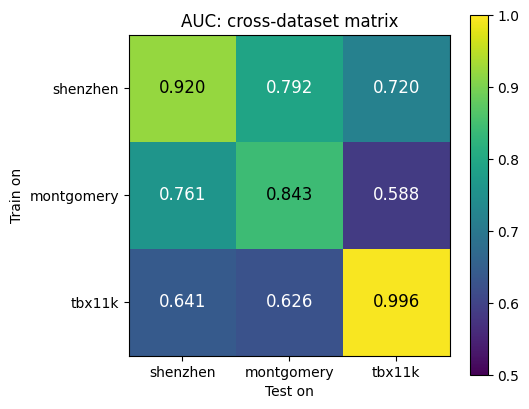

In [26]:
res = pd.read_csv(RES_CSV)
display(res[['train', 'test', 'eval_on', 'n', 'auc', 'auc_lo', 'auc_hi']].round(3))

piv = res.pivot(index='train', columns='test', values='auc').loc[DATASETS, DATASETS]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(piv.values, vmin=0.5, vmax=1.0, cmap='viridis')
ax.set_xticks(range(3)); ax.set_xticklabels(DATASETS); ax.set_yticks(range(3)); ax.set_yticklabels(DATASETS)
ax.set_xlabel('Test on'); ax.set_ylabel('Train on'); ax.set_title('AUC: cross-dataset matrix')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{piv.values[i, j]:.3f}', ha='center', va='center',
                color='white' if piv.values[i, j] < 0.8 else 'black', fontsize=12)
plt.colorbar(im); plt.tight_layout(); plt.savefig(RES / 'cross_dataset_heatmap.png', dpi=150); plt.show()

In [27]:
from sklearn.metrics import average_precision_score
rows = []
for tr in DATASETS:
    for te in DATASETS:
        d = np.load(RES / f'preds_{tr}_{te}.npz'); y, p = d['y'], sigmoid(d['logits'])
        rows.append(dict(train=tr, test=te, auprc=average_precision_score(y, p), prevalence=y.mean()))
ap = pd.DataFrame(rows); display(ap.round(3)); ap.to_csv(RES / 'auprc.csv', index=False)

,train,test,auprc,prevalence
0,shenzhen,shenzhen,0.945,0.510
1,shenzhen,montgomery,0.772,0.420
2,shenzhen,tbx11k,0.275,0.095
3,montgomery,shenzhen,0.798,0.508
4,montgomery,montgomery,0.878,0.429
5,montgomery,tbx11k,0.112,0.095
6,tbx11k,shenzhen,0.703,0.508
7,tbx11k,montgomery,0.529,0.420
8,tbx11k,tbx11k,0.977,0.095


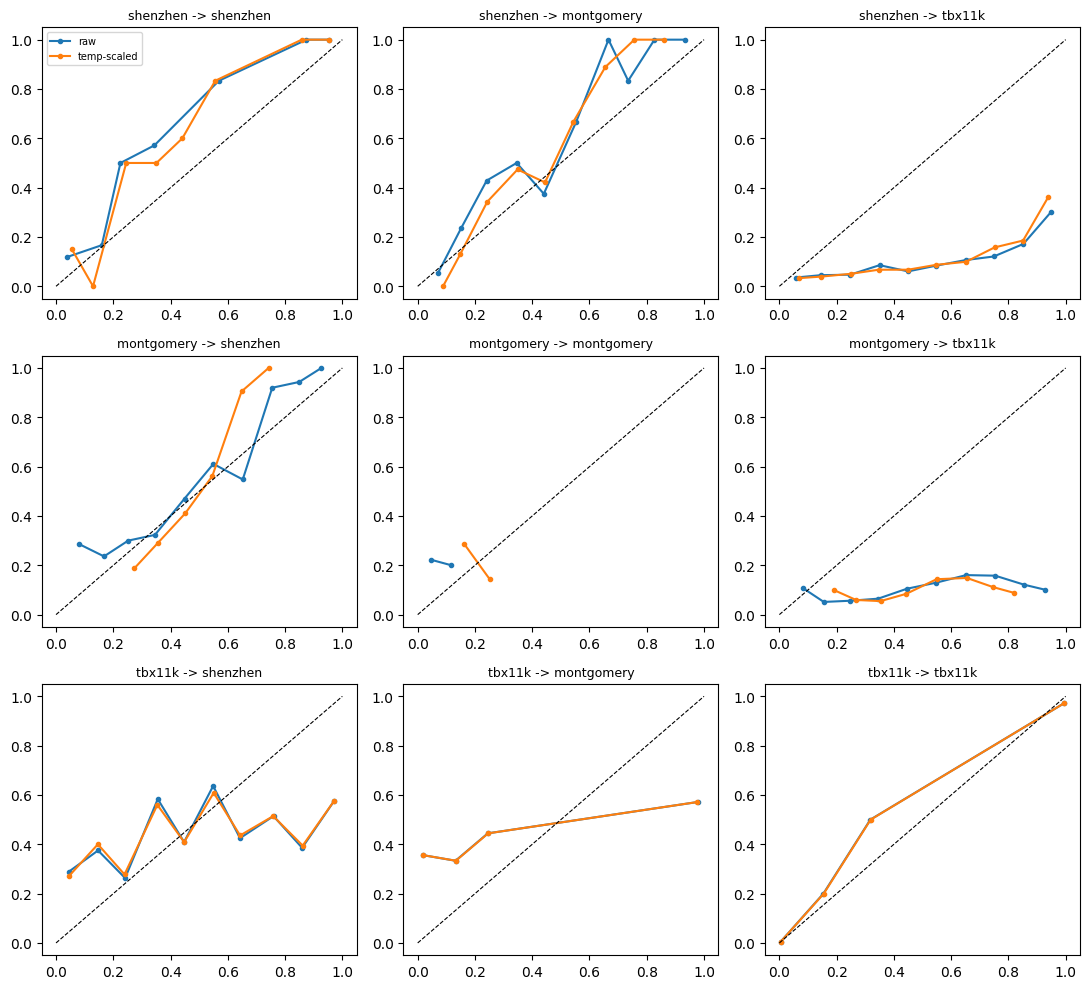

,train,test,T,ece_raw,ece_tempscaled
0,shenzhen,shenzhen,1.23,0.107,0.131
1,shenzhen,montgomery,1.23,0.111,0.091
2,shenzhen,tbx11k,1.23,0.326,0.334
3,montgomery,shenzhen,1.97,0.065,0.085
4,montgomery,montgomery,1.97,0.188,0.200
5,montgomery,tbx11k,1.97,0.416,0.416
6,tbx11k,shenzhen,1.01,0.331,0.329
7,tbx11k,montgomery,1.01,0.324,0.323
8,tbx11k,tbx11k,1.01,0.005,0.005


In [28]:
from scipy.optimize import minimize_scalar

def ece(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1); e = 0
    for a, b in zip(edges[:-1], edges[1:]):
        m = (p >= a) & (p < b) if b < 1 else (p >= a) & (p <= b)
        if m.any(): e += m.mean() * abs(y[m].mean() - p[m].mean())
    return e

def fit_temp(y, z):
    nll = lambda T: -np.mean(y * np.log(sigmoid(z / T) + 1e-9) + (1 - y) * np.log(1 - sigmoid(z / T) + 1e-9))
    return minimize_scalar(nll, bounds=(0.1, 10), method='bounded').x

rows = []
fig, axes = plt.subplots(len(DATASETS), len(DATASETS), figsize=(11, 10))
for i, tr in enumerate(DATASETS):
    v = np.load(RES / f'val_{tr}.npz'); T = fit_temp(v['y'], v['logits'])
    for j, te in enumerate(DATASETS):
        d = np.load(RES / f'preds_{tr}_{te}.npz'); y, z = d['y'], d['logits']
        p0, p1 = sigmoid(z), sigmoid(z / T)
        rows.append(dict(train=tr, test=te, T=round(T, 2), ece_raw=ece(y, p0), ece_tempscaled=ece(y, p1)))
        ax = axes[i, j]
        for p, lab in [(p0, 'raw'), (p1, 'temp-scaled')]:
            bins = np.linspace(0, 1, 11); idx = np.digitize(p, bins) - 1
            xs = [p[idx == k].mean() for k in range(10) if (idx == k).sum() > 3]
            ys = [y[idx == k].mean() for k in range(10) if (idx == k).sum() > 3]
            ax.plot(xs, ys, 'o-', label=lab, ms=3)
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8); ax.set_title(f'{tr} -> {te}', fontsize=9)
axes[0, 0].legend(fontsize=7); plt.tight_layout(); plt.savefig(RES / 'calibration.png', dpi=130); plt.show()
cal = pd.DataFrame(rows); display(cal.round(3)); cal.to_csv(RES / 'calibration.csv', index=False)

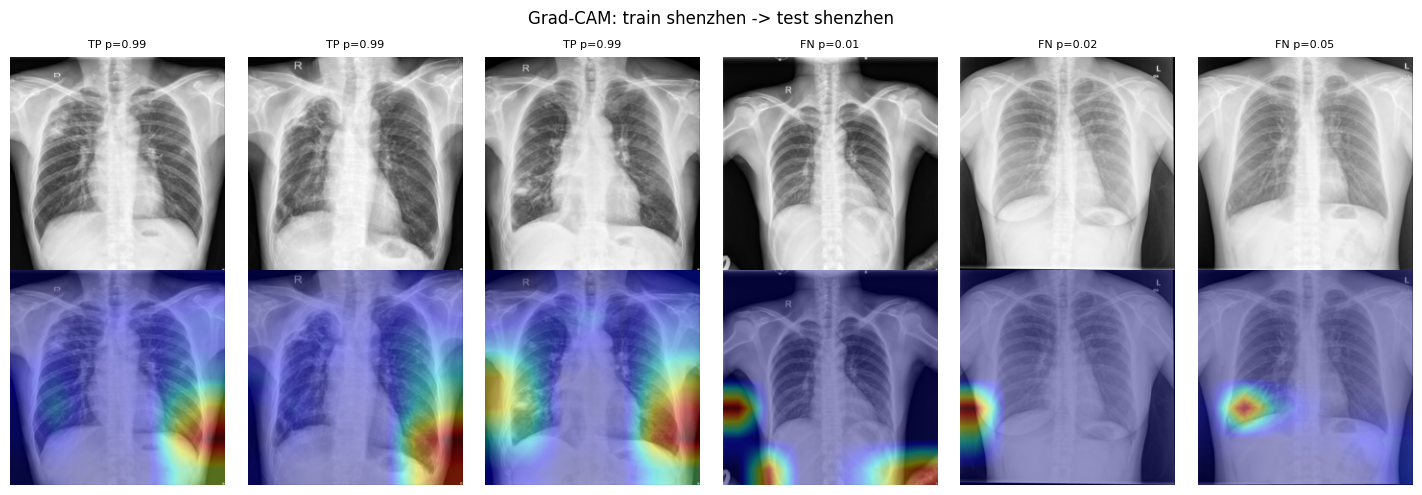

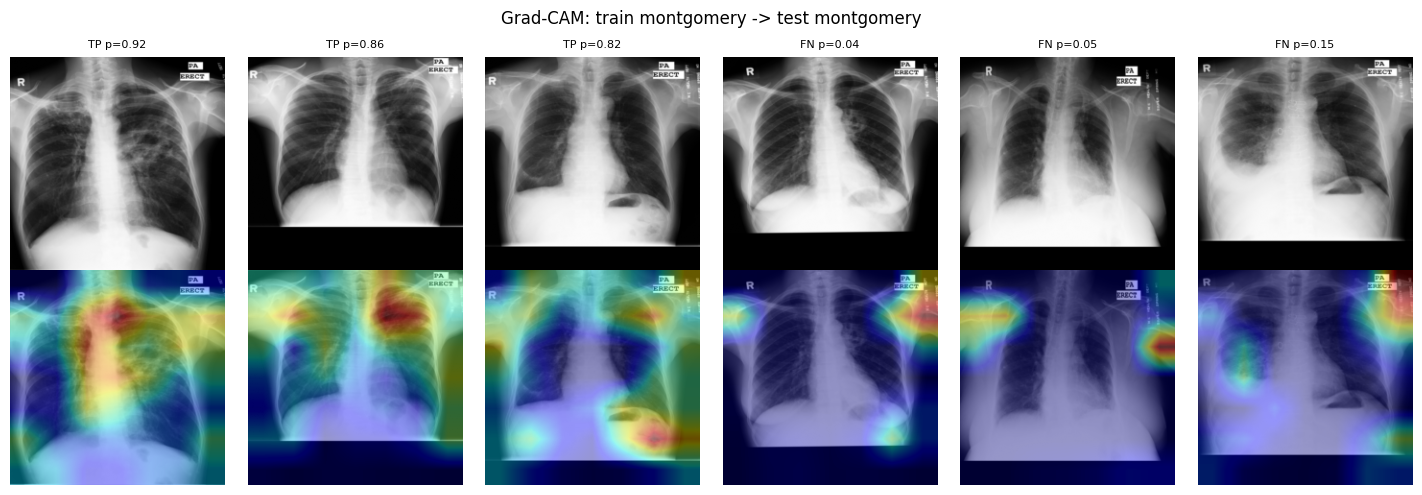

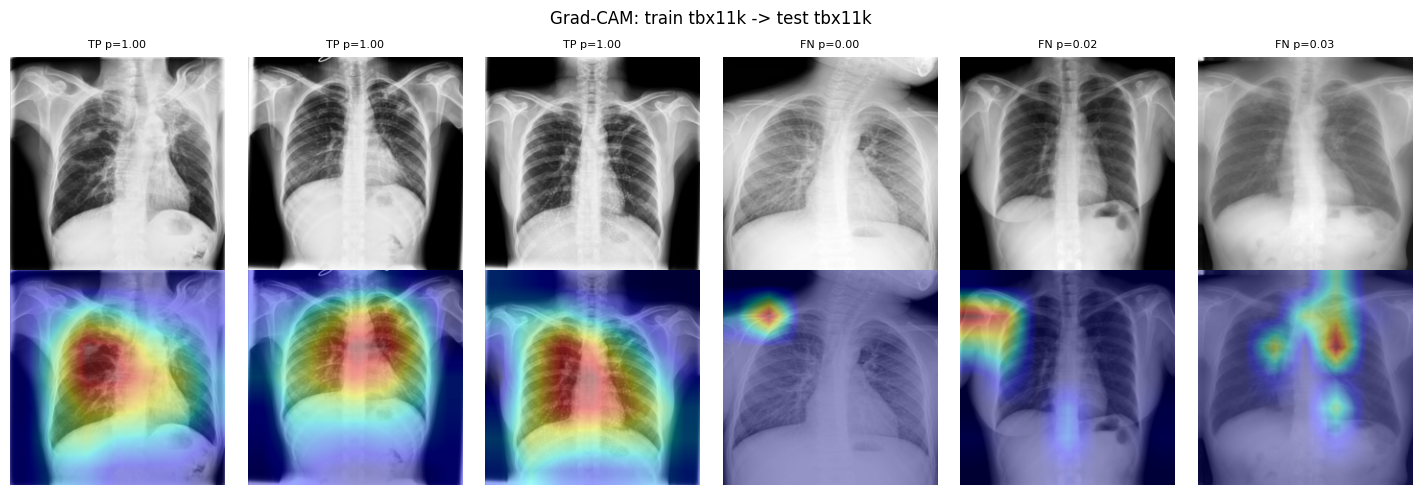

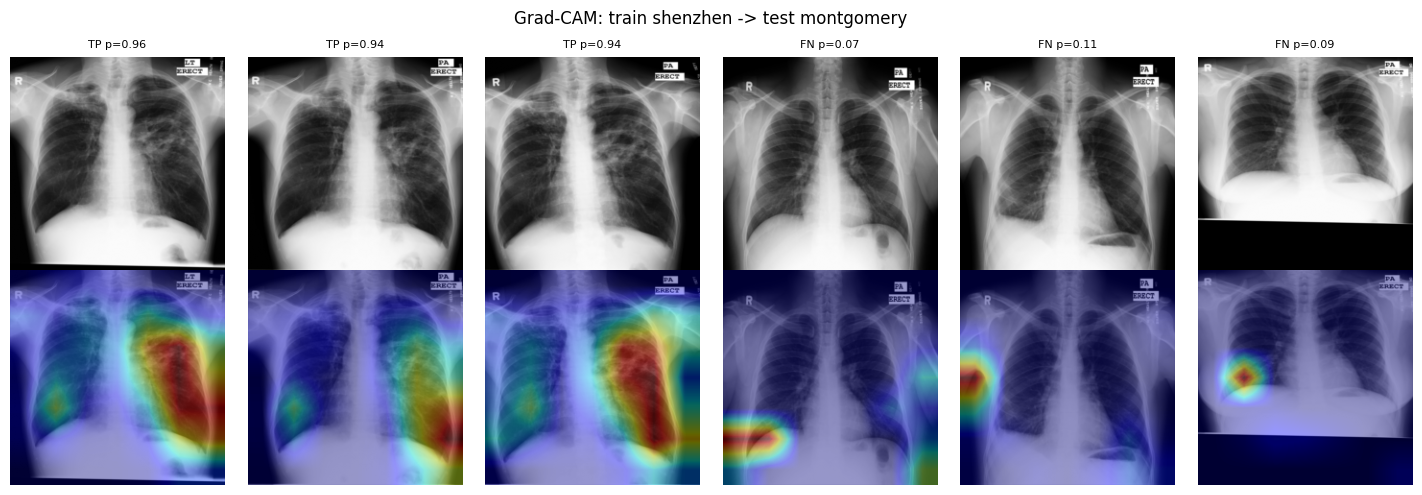

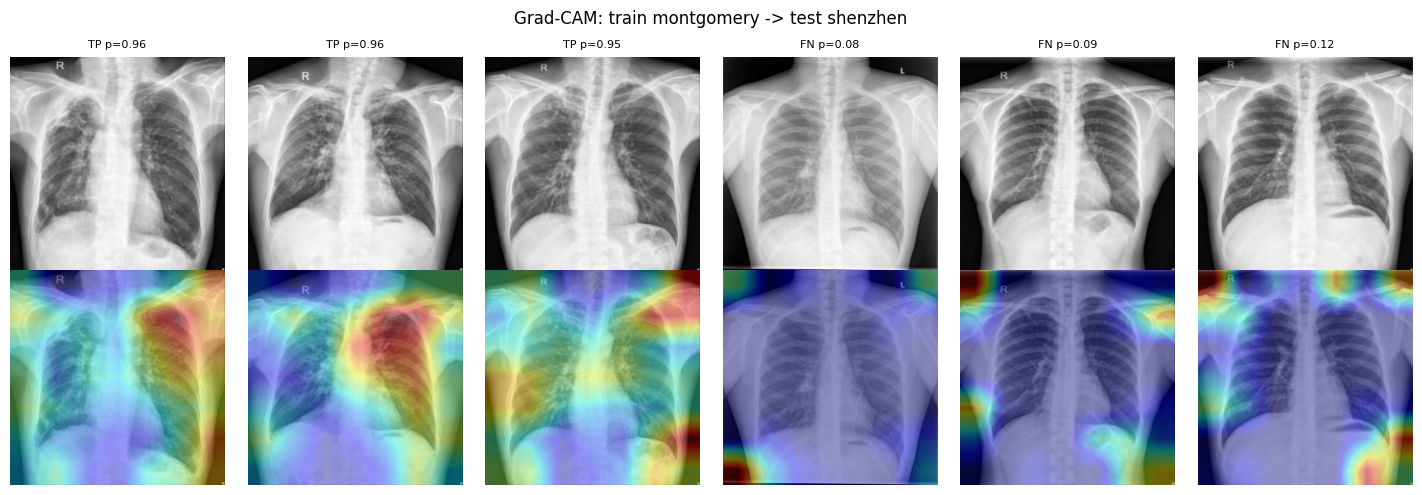

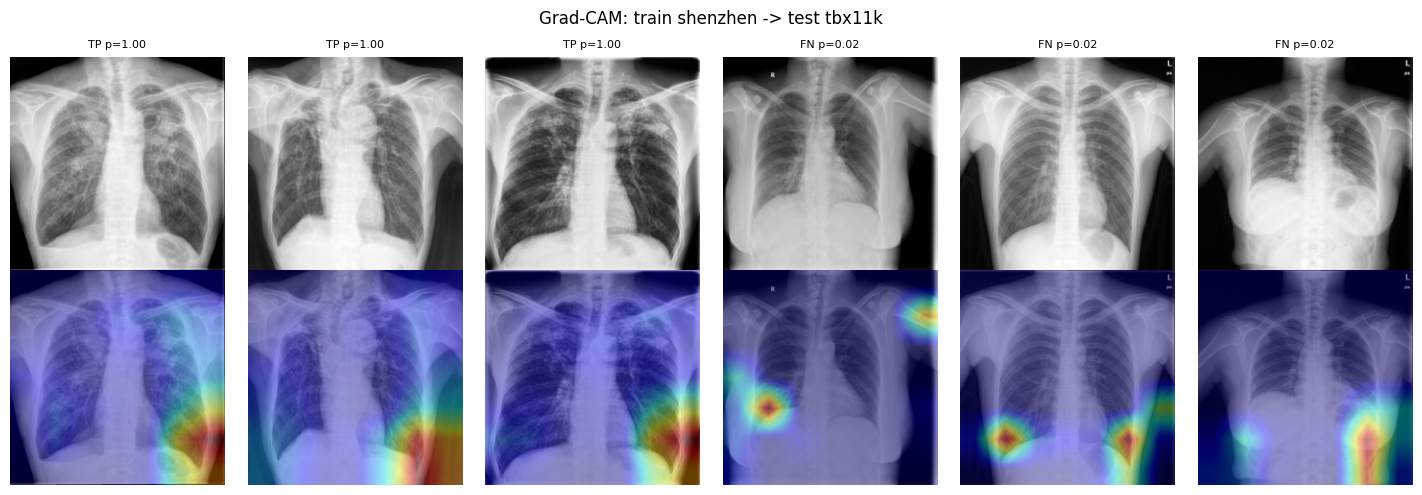

In [29]:
import cv2

def gradcam(model, x):                      # x: 1x3xHxW
    model.eval(); x = x.to(DEVICE).requires_grad_(False)
    feats = model.forward_features(x); feats.retain_grad()
    logit = model.forward_head(feats).reshape(-1)[0]
    model.zero_grad(); logit.backward()
    w = feats.grad.mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((w * feats).sum(1))[0].detach().cpu().numpy()
    cam = cv2.resize(cam, (224, 224)); cam -= cam.min(); cam /= (cam.max() + 1e-8)
    return cam, logit.item()

def show_cams(tr, te, n=6, fname=None):
    model = load_best(tr); d = np.load(RES / f'preds_{tr}_{te}.npz')
    y, z, idx = d['y'], d['logits'], d['idx']
    tp = np.where(y == 1)[0][np.argsort(-z[y == 1])][:n // 2]          # confident TB sahi
    fn = np.where(y == 1)[0][np.argsort(z[y == 1])][:n // 2]           # TB jo miss hue
    sel = list(tp) + list(fn); ds = CXRDataset(XS[te][idx], y)
    fig, axes = plt.subplots(2, len(sel), figsize=(2.4 * len(sel), 5))
    for c, k in enumerate(sel):
        xb, _ = ds[k]; cam, lg = gradcam(model, xb.unsqueeze(0))
        axes[0, c].imshow(XS[te][idx[k]], cmap='gray'); axes[0, c].axis('off')
        axes[0, c].set_title(('TP' if k in tp else 'FN') + f' p={sigmoid(lg):.2f}', fontsize=8)
        axes[1, c].imshow(XS[te][idx[k]], cmap='gray'); axes[1, c].imshow(cam, cmap='jet', alpha=0.4); axes[1, c].axis('off')
    plt.suptitle(f'Grad-CAM: train {tr} -> test {te}'); plt.tight_layout()
    plt.savefig(RES / (fname or f'gradcam_{tr}_{te}.png'), dpi=130); plt.show()
    del model; torch.cuda.empty_cache()

for tr in DATASETS:
    show_cams(tr, tr)                                   # in-domain
show_cams('shenzhen', 'montgomery'); show_cams('montgomery', 'shenzhen'); show_cams('shenzhen', 'tbx11k')

In [30]:
res = pd.read_csv(RES_CSV); rows = []
for _, r in res.iterrows():
    tr, te, thr = r['train'], r['test'], r['thr_src']
    d = np.load(RES / f'preds_{tr}_{te}.npz'); y, p, idx = d['y'], sigmoid(d['logits']), d['idx']
    pred = p >= thr; m = META[te].iloc[idx]
    for name, mask in [('TP', pred & (y == 1)), ('FN', ~pred & (y == 1)), ('FP', pred & (y == 0)), ('TN', ~pred & (y == 0))]:
        if mask.any():
            rows.append(dict(train=tr, test=te, group=name, n=int(mask.sum()),
                             brightness=m.brightness.values[mask].mean(), contrast=m.contrast.values[mask].mean()))
fa = pd.DataFrame(rows); display(fa.round(1)); fa.to_csv(RES / 'failure_analysis.csv', index=False)

# cross-dataset par sensitivity/specificity drop
display(res[['train', 'test', 'sens_at_srcthr', 'spec_at_srcthr', 'f1_at_srcthr', 'spec_at_own_90sens']].round(3))

,train,test,group,n,brightness,contrast
0,shenzhen,shenzhen,TP,46,151.0,65.0
1,shenzhen,shenzhen,FN,5,161.2,63.4
2,shenzhen,shenzhen,FP,9,160.4,57.9
3,shenzhen,shenzhen,TN,40,158.8,63.3
4,shenzhen,montgomery,TP,53,113.5,82.0
5,shenzhen,montgomery,FN,5,114.8,82.4
6,shenzhen,montgomery,FP,46,111.3,80.5
7,shenzhen,montgomery,TN,34,113.8,84.9
8,shenzhen,tbx11k,TP,702,132.4,69.3
9,shenzhen,tbx11k,FN,99,128.8,70.8


,train,test,sens_at_srcthr,spec_at_srcthr,f1_at_srcthr,spec_at_own_90sens
0,shenzhen,shenzhen,0.902,0.816,0.868,0.816
1,shenzhen,montgomery,0.914,0.425,0.675,0.425
2,shenzhen,tbx11k,0.876,0.321,0.211,0.275
3,montgomery,shenzhen,1.000,0.003,0.674,0.304
4,montgomery,montgomery,0.778,0.417,0.609,0.333
5,montgomery,tbx11k,0.998,0.002,0.174,0.183
6,tbx11k,shenzhen,0.435,0.804,0.535,0.187
7,tbx11k,montgomery,0.121,0.912,0.194,0.175
8,tbx11k,tbx11k,0.808,0.998,0.886,0.996
